# Machine Learning Lab 4

# Exploratory Data Analysis 

## Dataset
UCI Online Retail Dataset

## Objective
Perform exploratory data analysis (EDA) using Pandas, Matplotlib, and Seaborn to understand the dataset, explore its variables, distributions, relationships, and trends.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading and Initial Inspection

In [2]:
df = pd.read_csv("Online_Retail.csv")

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
df.shape

(541909, 8)

In [5]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [6]:
df.dtypes

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

## Data Quality Analysis

In [7]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(5268)

In [9]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [11]:
df.describe(include='str')

,InvoiceNo,StockCode,Description,InvoiceDate,Country
count,541909,541909,540455,541909,541909
unique,25900,4070,4223,23260,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,31/10/2011 14:41,United Kingdom
freq,1114,2313,2369,1114,495478


In [12]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True)

In [13]:
df.dtypes

InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

## Numerical Analysis

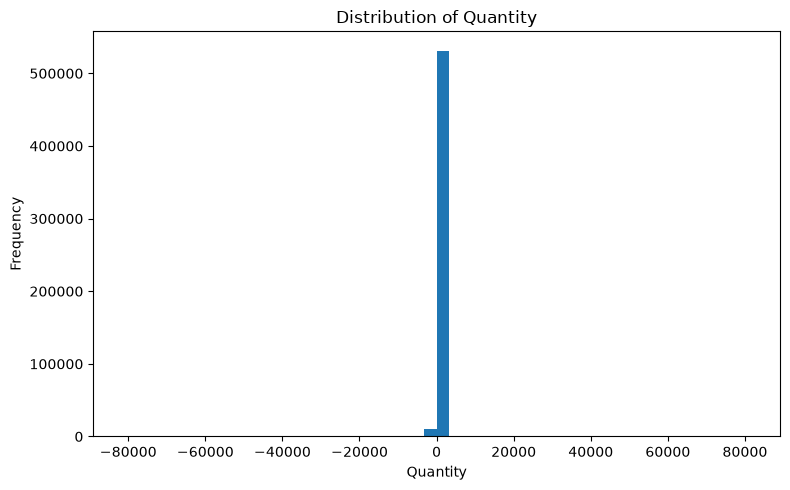

In [18]:
plt.figure(figsize=(8, 5))
plt.hist(df['Quantity'], bins=50)
plt.title('Distribution of Quantity')
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Interpretation

The initial histogram shows that the distribution of Quantity is highly concentrated around a relatively small range, while extreme values extend the x-axis considerably. These extreme values make the main distribution difficult to visualize clearly. Therefore, a focused histogram is used to examine the distribution within the range from -100 to 100 without modifying the original dataset.

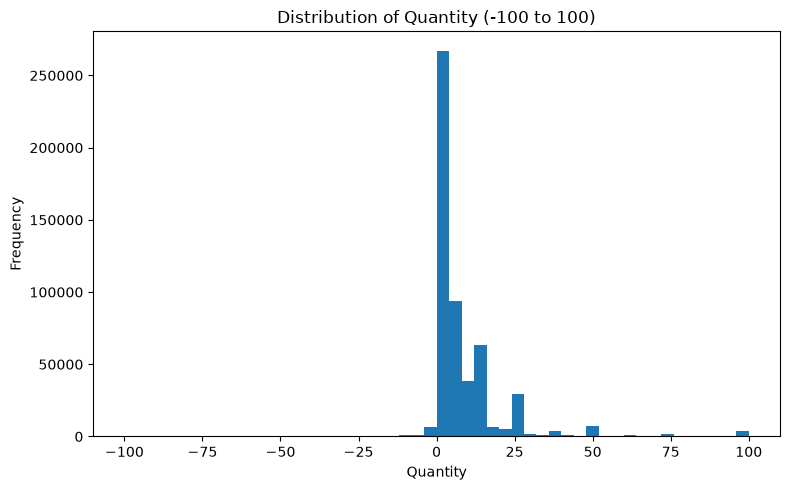

In [17]:
quantity_plot = df.loc[df['Quantity'].between(-100, 100), 'Quantity']

plt.figure(figsize=(8, 5))
plt.hist(quantity_plot, bins=50)
plt.title('Distribution of Quantity (-100 to 100)')
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Interpretation

The focused histogram provides a clearer view of the distribution of Quantity for values between -100 and 100. Most observations are concentrated at relatively low quantities, with a smaller number of negative and higher quantity values. This indicates that the variable is not evenly distributed and contains values that extend beyond the main concentration of the data.

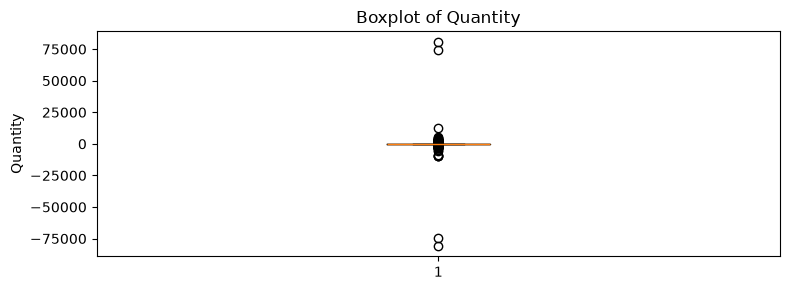

In [19]:
plt.figure(figsize=(8, 3))
plt.boxplot(df['Quantity'])
plt.title('Boxplot of Quantity')
plt.ylabel('Quantity')
plt.tight_layout()
plt.show()

### Interpretation

The boxplot shows that Quantity contains several extreme outliers, with values extending to approximately -80,995 and 80,995. Because these extreme values are far from the main concentration of observations, the central box is compressed near zero and is difficult to distinguish visually. This indicates substantial variability and the presence of extreme observations in the dataset.

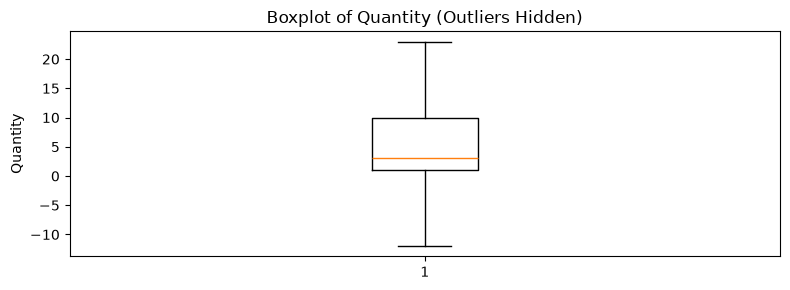

In [22]:
plt.figure(figsize=(8, 3))
plt.boxplot(df['Quantity'], showfliers=False)
plt.title('Boxplot of Quantity (Outliers Hidden)')
plt.ylabel('Quantity')
plt.tight_layout()
plt.show()

### Interpretation

With the extreme outliers hidden for visualization, the boxplot shows that the median Quantity is approximately 3 units. The middle 50% of observations lies roughly between 1 and 10 units, while the whiskers extend from approximately -12 to 23. This indicates that most transactions involve relatively small quantities, although the dataset also contains many observations outside this central range.

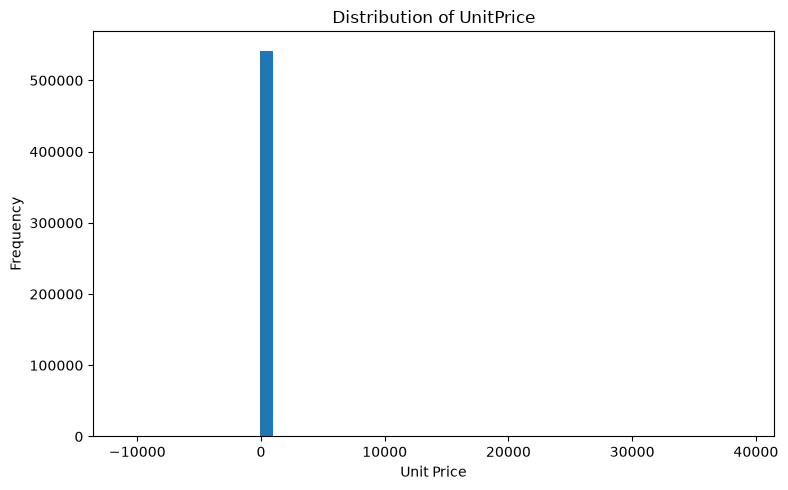

In [23]:
plt.figure(figsize=(8, 5))
plt.hist(df['UnitPrice'], bins=50)
plt.title('Distribution of UnitPrice')
plt.xlabel('Unit Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [24]:
df['UnitPrice'].quantile([0.01, 0.25, 0.50, 0.75, 0.95, 0.99])

0.01     0.19
0.25     1.25
0.50     2.08
0.75     4.13
0.95     9.95
0.99    18.00
Name: UnitPrice, dtype: float64

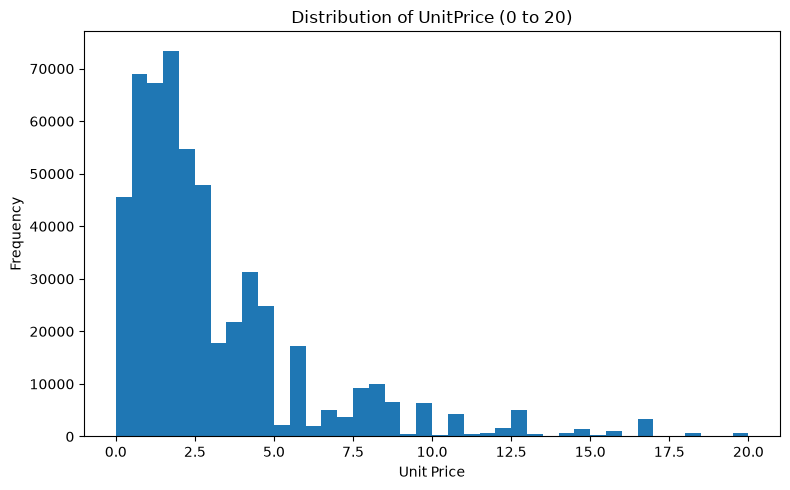

In [25]:
unit_price_plot = df.loc[df['UnitPrice'].between(0, 20), 'UnitPrice']

plt.figure(figsize=(8, 5))
plt.hist(unit_price_plot, bins=40)
plt.title('Distribution of UnitPrice (0 to 20)')
plt.xlabel('Unit Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Interpretation

The focused histogram shows that UnitPrice is strongly concentrated at relatively low values. Most observations fall between 0 and 5, with the frequency decreasing as the unit price increases. A smaller number of observations extends to higher prices, indicating a right-skewed distribution. The original dataset also contains extreme values beyond this visualization range, which will be examined separately using a boxplot.

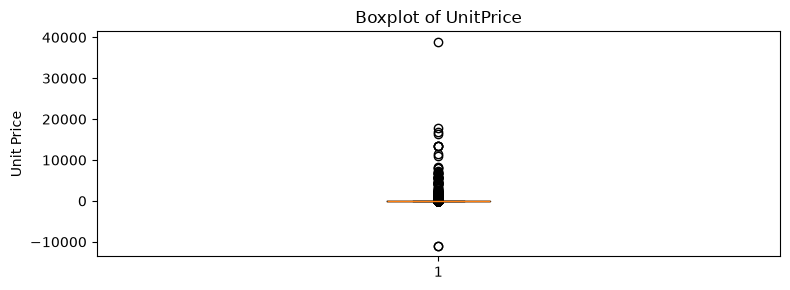

In [26]:
plt.figure(figsize=(8, 3))
plt.boxplot(df['UnitPrice'])
plt.title('Boxplot of UnitPrice')
plt.ylabel('Unit Price')
plt.tight_layout()
plt.show()

### Interpretation

The boxplot of UnitPrice shows a large number of extreme outliers. Most observations are concentrated close to zero, while some values extend to very high positive prices, with the maximum reaching approximately 38,970. There is also a negative extreme value of approximately -11,062. These extreme observations compress the central box and make the main distribution difficult to visualize. The outliers are retained because they should be investigated before deciding whether any data cleaning is necessary.

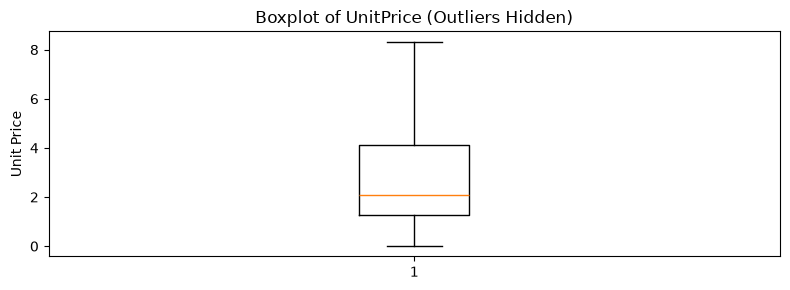

In [27]:
plt.figure(figsize=(8, 3))
plt.boxplot(df['UnitPrice'], showfliers=False)
plt.title('Boxplot of UnitPrice (Outliers Hidden)')
plt.ylabel('Unit Price')
plt.tight_layout()
plt.show()

### Interpretation

With the outlier points hidden for visualization, the central distribution of UnitPrice becomes clearer. The median is approximately 2.08, while the middle 50% of observations lies roughly between 1.25 and 4.13. The upper whisker extends to approximately 8.3, indicating that most of the central distribution consists of relatively low unit prices. This visualization provides a clearer view of the typical UnitPrice values while the original boxplot demonstrates the presence of extreme observations.

## Country Analysis

In [28]:
country_counts = df['Country'].value_counts().head(10)

country_counts

Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64

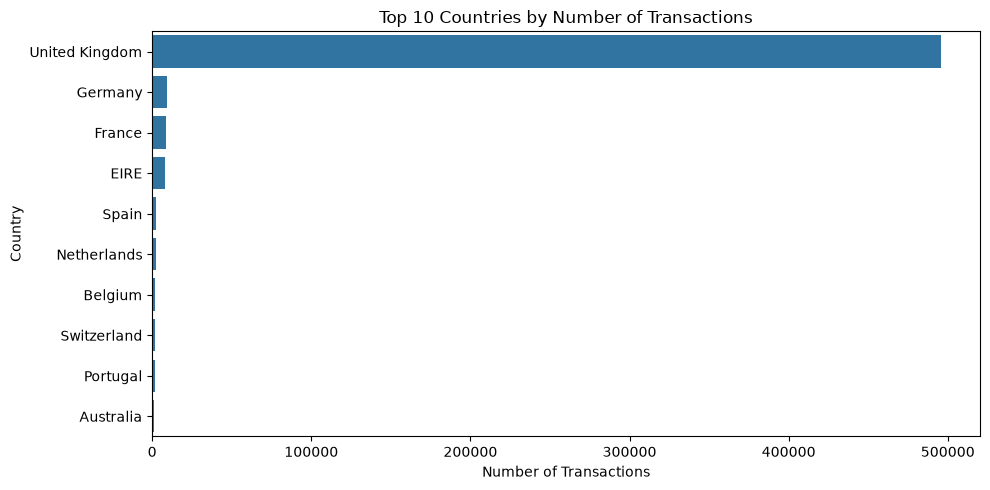

In [29]:
plt.figure(figsize=(10, 5))
sns.barplot(x=country_counts.values, y=country_counts.index)
plt.title('Top 10 Countries by Number of Transactions')
plt.xlabel('Number of Transactions')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

### Interpretation

The bar chart shows that the United Kingdom has by far the highest number of transaction records among the top 10 countries, with 495,478 records. Germany and France follow with 9,495 and 8,557 records, respectively. The remaining countries have substantially fewer records. This indicates that the dataset is highly concentrated in the United Kingdom, while transactions from other countries represent a much smaller proportion of the recorded transactions.

## Time-Based Analysis

In [30]:
monthly_transactions = (
    df.groupby(df['InvoiceDate'].dt.to_period('M'))
      .size()
)

monthly_transactions

InvoiceDate
2010-12    42481
2011-01    35147
2011-02    27707
2011-03    36748
2011-04    29916
2011-05    37030
2011-06    36874
2011-07    39518
2011-08    35284
2011-09    50226
2011-10    60742
2011-11    84711
2011-12    25525
Freq: M, dtype: int64

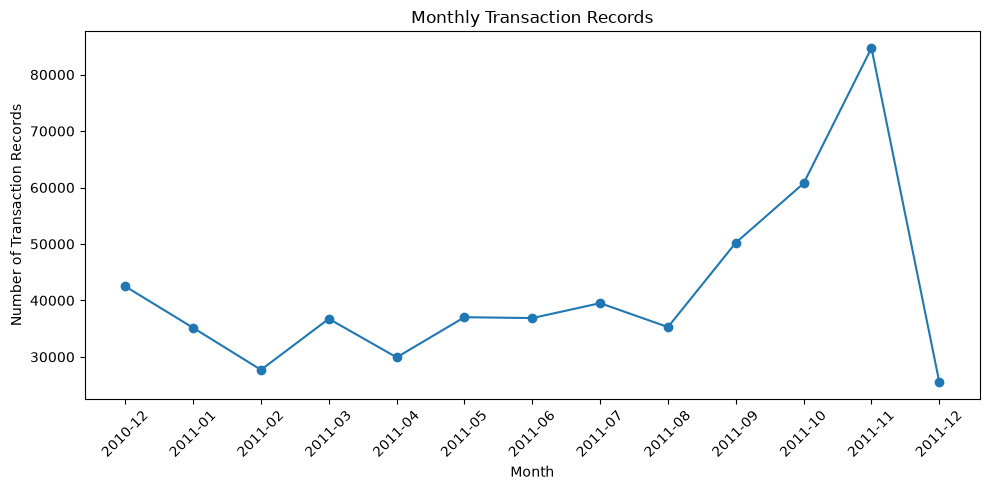

In [31]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_transactions.index.astype(str), monthly_transactions.values, marker='o')
plt.title('Monthly Transaction Records')
plt.xlabel('Month')
plt.ylabel('Number of Transaction Records')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretation

The monthly analysis shows variation in the number of transaction records over the observed period. The number of records generally increases toward the later months of 2011, reaching the highest level in November with 84,711 records. December shows a notable decrease to 25,525 records. Earlier months also show fluctuations, with February having the lowest number of records during most of the year at 27,707. Overall, the results indicate changes in transaction activity over time, with substantially higher recorded activity toward the end of 2011.

## Grouping and Aggregation

In [32]:
country_summary = df.groupby('Country').agg(
    TransactionRecords=('InvoiceNo', 'size'),
    TotalQuantity=('Quantity', 'sum'),
    AverageUnitPrice=('UnitPrice', 'mean')
)

country_summary.sort_values('TransactionRecords', ascending=False).head(10)

,TransactionRecords,TotalQuantity,AverageUnitPrice
Country,,,
United Kingdom,495478,4263829,4.532422
Germany,9495,117448,3.966930
France,8557,110480,5.028864
EIRE,8196,142637,5.911077
Spain,2533,26824,4.987544
Netherlands,2371,200128,2.738317
Belgium,2069,23152,3.644335
Switzerland,2002,30325,3.403442
Portugal,1519,16180,8.582976


In [34]:
top_quantity_countries = country_summary.sort_values(
    'TotalQuantity', ascending=False
).head(10)

top_quantity_countries

,TransactionRecords,TotalQuantity,AverageUnitPrice
Country,,,
United Kingdom,495478,4263829,4.532422
Netherlands,2371,200128,2.738317
EIRE,8196,142637,5.911077
Germany,9495,117448,3.966930
France,8557,110480,5.028864
Australia,1259,83653,3.220612
Sweden,462,35637,3.910887
Switzerland,2002,30325,3.403442
Spain,2533,26824,4.987544


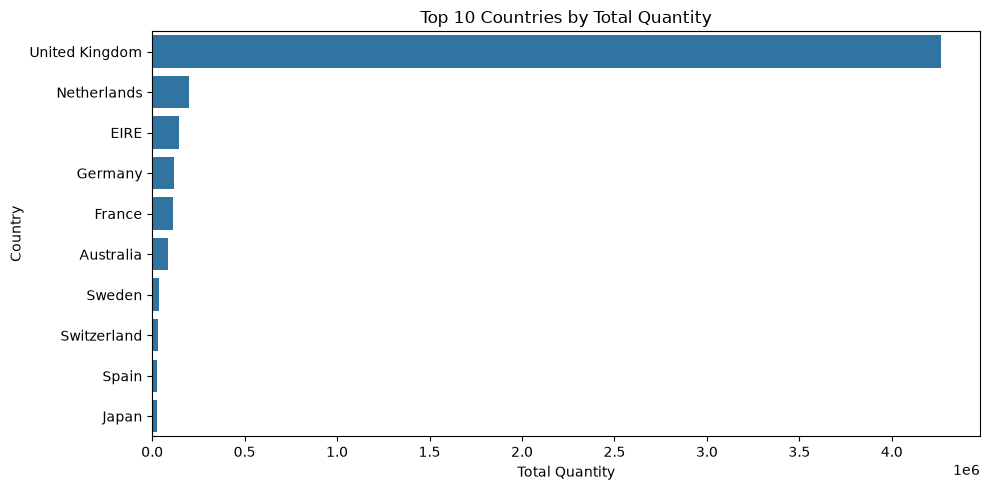

In [35]:
plt.figure(figsize=(10, 5))
sns.barplot(
    x=top_quantity_countries['TotalQuantity'],
    y=top_quantity_countries.index
)
plt.title('Top 10 Countries by Total Quantity')
plt.xlabel('Total Quantity')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

### Interpretation

The bar chart shows the top 10 countries based on total recorded quantity. The United Kingdom has by far the highest total quantity, with approximately 4.26 million units recorded. The Netherlands ranks second with approximately 200,000 units, followed by EIRE, Germany, and France. The remaining countries have substantially lower total recorded quantities.

The large difference between the United Kingdom and the other countries indicates that the dataset is highly concentrated in the UK. Since the Quantity variable includes both positive and negative values, the totals represent the net quantity recorded in the dataset rather than only completed sales.

## Relationship Analysis

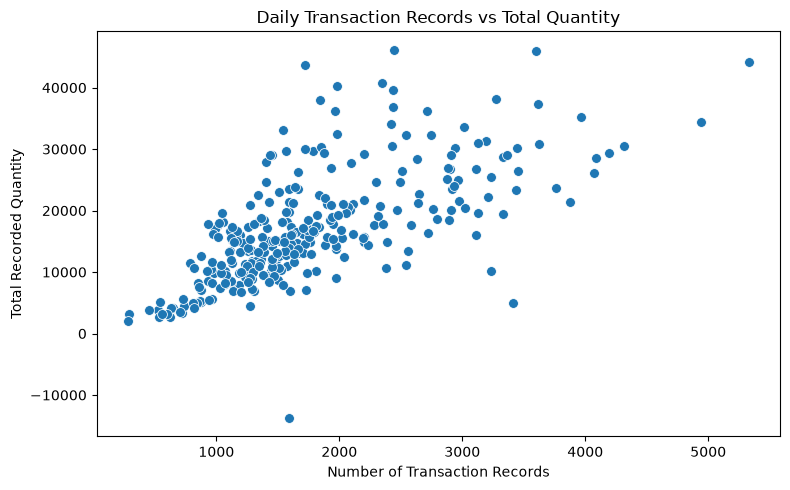

In [39]:
daily_summary = df.groupby(
    df['InvoiceDate'].dt.date
).agg(
    TransactionRecords=('InvoiceNo', 'size'),
    TotalQuantity=('Quantity', 'sum')
)

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=daily_summary,
    x='TransactionRecords',
    y='TotalQuantity',
    s=50
)

plt.title('Daily Transaction Records vs Total Quantity')
plt.xlabel('Number of Transaction Records')
plt.ylabel('Total Recorded Quantity')
plt.tight_layout()
plt.show()

### Interpretation

The scatter plot shows a generally positive relationship between the number of daily transaction records and the total recorded quantity. As the number of transaction records increases, the total recorded quantity generally tends to increase as well.

However, the points are not perfectly aligned, indicating that the same number of transaction records can correspond to different total quantities. There are also a few unusual observations, including a day with a negative total recorded quantity. Overall, the plot suggests that transaction activity and total recorded quantity are positively associated, although other factors may also contribute to the variation.

## Conclusion

The exploratory data analysis provided an overview of the UCI Online Retail dataset and revealed several important characteristics of the data. The dataset contains 541,909 transaction records and includes numerical, categorical, and date/time variables.

The analysis showed that Quantity and UnitPrice are highly concentrated around relatively small values, while the dataset also contains extreme observations. Missing values were identified in Description and CustomerID, and duplicate records were also present. Country analysis showed that the majority of transaction records came from the United Kingdom.

The time-based analysis revealed variations in transaction activity across the observed months, with higher activity toward the later months of 2011. Grouping and aggregation further showed differences in transaction records and total recorded quantity across countries. Overall, the EDA helped identify the main patterns, distributions, variations, and data-quality characteristics of the dataset without modifying or removing the original observations.